# Core Imports

In [1]:
# Generic Imports
import re
from collections import defaultdict
from ast import literal_eval

# Numeric imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# File I/O
from pathlib import Path
import csv, json

# Cheminformatics
from rdkit import Chem
from rdkit.Chem import rdChemReactions
from rdkit.Chem.Draw import IPythonConsole

DIM    = 300
ASPECT = 3/2
IPythonConsole.molSize = (int(ASPECT*DIM), DIM)   # Change image size

# Inspecting monomer dataset

In [2]:
from src.utils.dataIO import read_monomer_data
from src.utils.datafmt import parse_field_names_and_roles


DATA_DIR = Path('src/monomer_data')

input_data_path = DATA_DIR / 'PolyID_master.csv'
# input_data_path = DATA_DIR / 'subsample_IPU.csv'

# load and parse monomer data file from disc
monomer_df = read_monomer_data([input_data_path])[0]
monomer_df.set_index(monomer_df.columns[0], inplace=True) # alternative to index_cols arg in read function
field_names, field_roles = parse_field_names_and_roles(monomer_df)
monomer_df.rename(columns=field_names, inplace=True)
print(len(monomer_df))

# generate chemically-unique counterpart
monomer_df_unique = monomer_df.drop_duplicates('smiles_canonical')
print(len(monomer_df_unique))

3199
2528


## Sort by polymerization mechanism and #monomers, obtain respective counts and colors

In [3]:
from polymerist.graphics import plotutils

keys = ['mechanism']#, 'num_monomers']

grouper = monomer_df.groupby(keys, as_index=False) # group by mechanism name, preserving original indices
counts : pd.DataFrame = grouper.size().sort_values(by='size')
frames : dict[str, pd.DataFrame] = {
    mech : grouper.get_group(mech)
        for mech in grouper.groups
}

Text(0.5, 1.0, 'Number of SMILES by mechanism (3199 total, 2528 unique)')

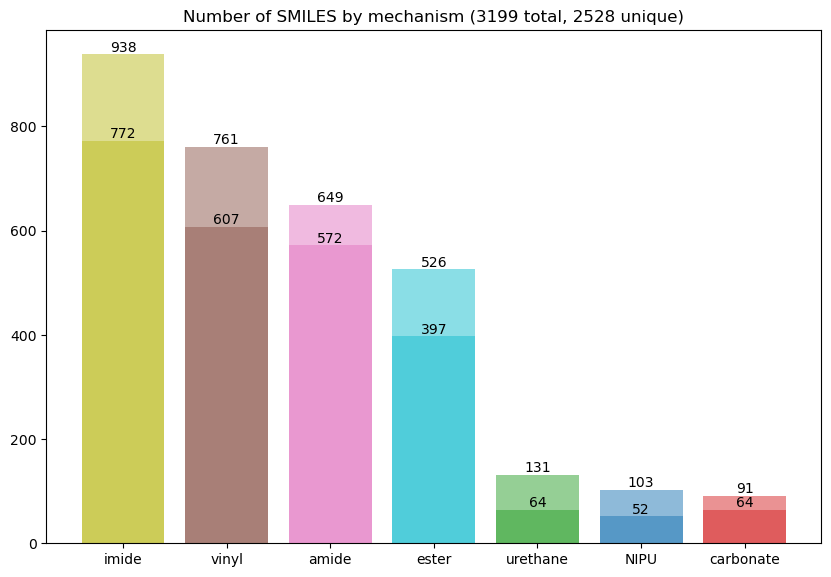

In [4]:
dfs : dict[str, pd.DataFrame] = {
    'total'  : monomer_df,
    'unique' : monomer_df_unique,
}
prop : str = 'mechanism'

# generate colorbar with unique color for each mechanism
cdict, carr = plotutils.label_discrete_cmap(
    cmap=plt.get_cmap('tab10'),
    color_names=monomer_df[prop].unique(),
    hues_per_color=1
)
# plt.imshow(carr)

# plot distributions of property across variants of dataframe
fig, ax = plotutils.presize_subplots(1, 1, scale=10, elongation=2/3)
alpha_dropoff = 1.0 / len(dfs)

title_counts : list[str] = []
for label, dataframe in dfs.items(): 
    title_counts.append(f'{len(dataframe)} {label}')
    
    prop_counts : pd.Series = dataframe[prop].value_counts()
    bar_labels, bar_heights = prop_counts.index, prop_counts.values
    bar_colors = [cdict[label][:-1] + (alpha_dropoff,) for label in bar_labels] # split transparency uniformly amongst dataframes
    
    bars = ax.bar(bar_labels, bar_heights, color=bar_colors)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), bar.get_height(), ha='center', va='bottom')
        
count_str = ', '.join(title_counts)        
ax.set_title(f'Number of SMILES by {prop} ({count_str})')
# fig.savefig(f'monomer_data_raw/monomers_by_{prop}.png', bbox_inches='tight')

## Inspecting vinyl R-groups

In [5]:
from typing import Generator, Iterable, Optional, Sequence

from polymerist.rdutils.labeling.molwise import (
    atom_ids_by_map_nums,
    assign_ordered_atom_map_nums,
    has_fully_mapped_atoms,
    clear_atom_map_nums,
    clear_atom_isotopes,
)

def extract_vinyl_R_groups(
        molecule : Chem.Mol, 
        mapped_query_mol : Chem.Mol, 
        r_group_bond_atom_nums : Iterable[tuple[int, int]], 
        dummy_labels : Optional[Sequence[tuple[int, int]]]=None,
    ) -> Generator[Chem.Mol, None, None]:
    '''yields molecule fragments resulting from removal of each double-bonded carbon found in the molecule'''
    # sanitize dummy labels list
    if dummy_labels is None:
        dummy_labels = []
    else:
        assert len(dummy_labels) == len(r_group_bond_atom_nums)
    
    # query for vinyls
    mapped_molecule = assign_ordered_atom_map_nums(molecule)
    assert has_fully_mapped_atoms(mapped_molecule)
    assert has_fully_mapped_atoms(mapped_query_mol)
    
    for match_indices in mapped_molecule.GetSubstructMatches(mapped_query_mol, useChirality=False):
        modmol = Chem.RWMol(mapped_molecule) # create new editable copy of the molecule for each vinyl bond
        # generate correspondence between query map numbers and atom ids in queried molecule
        query_map_to_match_id : dict[int, int] = { # map from query map numbers to atom indices in the match
            atom.GetAtomMapNum() : match_id # relies on the fact that match atoms are returned in the same order as they appear in the query Mol
                for (atom, match_id) in zip(mapped_query_mol.GetAtoms(), match_indices)
        }
        
        # identify indices of objects to remove
        bond_ids_to_cut : list[int] = sorted((
                modmol.GetBondBetweenAtoms(
                    query_map_to_match_id[bond_start],
                    query_map_to_match_id[bond_end],
                ).GetIdx()
                    for (bond_start, bond_end) in r_group_bond_atom_nums
            ),
            reverse=True, # sort in descending order so each deletion doesn't affect those that follow it
        )
        
        # remove atom and bond targets and yield appropriate fragments
        frag_mol = Chem.FragmentOnBonds(modmol, bondIndices=bond_ids_to_cut, addDummies=True, dummyLabels=dummy_labels)
        for fragment in Chem.GetMolFrags(frag_mol, asMols=True):
            if fragment.GetSubstructMatch(mapped_query_mol): # don't return the central vinyl carbon fragments
                continue
            
            yield fragment

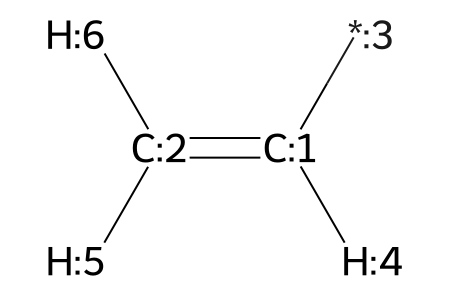

[(1, 3)]


In [6]:
# define vinyl group query and associated atom map numbers
# CC_DOUBLE_BOND_QUERY = Chem.MolFromSmarts('[C:1](-[*:3])(-[*:4])=[C:2](-[*:5])-[*:6]')
# CC_DOUBLE_BOND_ATOM_MAP_NUMS : tuple[int] = (1, 2) # map numbers on the vinyl carbons
# R_GROUP_MAP_NUMS : tuple[int] = (3, 4, 5, 6)  # map numbers of R-group bridgehead atoms

VINYL_QUERY = Chem.MolFromSmarts('[C:1](-[*:3])(-[H:4])=[C:2](-[H:5])-[H:6]')
VINYL_ATOM_MAP_NUMS : tuple[int] = (1, 2) # map numbers on the vinyl carbons
R_GROUP_MAP_NUMS : tuple[int] = (3,)  # map numbers of R-group bridgehead atoms

R_GROUP_BOND_MAP_NUMS : list[tuple[int, int]] = [  # select R-group-to-vinyl bonds for severance
    (vinyl_map_num, r_group_map_num)
        for vinyl_map_num in VINYL_ATOM_MAP_NUMS
            for r_group_map_num in R_GROUP_MAP_NUMS
                if VINYL_QUERY.GetBondBetweenAtoms(*atom_ids_by_map_nums(VINYL_QUERY, vinyl_map_num, r_group_map_num)) is not None
]

display(VINYL_QUERY)
print(R_GROUP_BOND_MAP_NUMS)

### Extract out unique R-group fragments by query

In [7]:
from rdkit import RDLogger                                                                                                                                                               
from rich.progress import track


unique_R_groups : set[Chem.Mol]  = set()
unique_R_group_SMILES : set[str] = set()

subframe = monomer_df_unique.groupby('mechanism').get_group('vinyl')
num_mols = len(subframe)

not_wholly_vinylic : list[tuple[int, str]] = [] # catalogue all monomer(s) for which not ALL parts are vinyls
RDLogger.DisableLog('rdApp.warning') # temporarily suppress unmapped hydrogen warnings
for i, row in track(subframe.iterrows(), description='Extracting unique vinyl R-groups...', total=num_mols):
    combo_mol = Chem.MolFromSmiles(row.smiles_explicit, sanitize=False)

    all_parts_vinylic : bool = True
    for indiv_mol in Chem.GetMolFrags(combo_mol, asMols=True):
        if not indiv_mol.HasSubstructMatch(VINYL_QUERY):
            all_parts_vinylic = False
            continue
        
        for frag in extract_vinyl_R_groups(
            indiv_mol, 
            mapped_query_mol=VINYL_QUERY, 
            r_group_bond_atom_nums=R_GROUP_BOND_MAP_NUMS, 
            dummy_labels=[(j, j) for (i, j) in R_GROUP_BOND_MAP_NUMS]
        ):
            unmapped_frag = clear_atom_map_nums(clear_atom_isotopes(frag))
            canon_smi = Chem.CanonSmiles(Chem.MolToSmiles(unmapped_frag))
            if canon_smi not in unique_R_group_SMILES:
                unique_R_group_SMILES.add(canon_smi)
                unique_R_groups.add(unmapped_frag)
    
    if not all_parts_vinylic:
        not_wholly_vinylic.append((i, row.smiles_explicit, row.smiles_canonical))
RDLogger.EnableLog('rdApp.warning') # re-enable warnings for other code



Output()

In [8]:
fake_vinyls = pd.DataFrame.from_records( # convert records to dataframe for ease of indexing
    not_wholly_vinylic, columns=[
        'vinyl_index',
         'smiles_explicit',
         'smiles_canonical',
    ],
    index='vinyl_index'
)       

fake_vinyl_canon_smi = set(fake_vinyls['smiles_canonical']) # cache set to avoid lookup for each function call
fake_vinyl_idxs = monomer_df_unique['smiles_canonical'].map(lambda s : s in fake_vinyl_canon_smi)

monomer_df_unique_real_vinyls = monomer_df_unique[~fake_vinyl_idxs]

In [10]:
# save results to file
outdir = Path('monomer_data_fmt')
outdir.mkdir(exist_ok=True)

with (outdir / 'unique_vinyl_R_groups.txt').open('w') as file:
    for smiles in sorted(unique_R_group_SMILES):
        file.write(f'{smiles}\n')

monomer_df_unique_real_vinyls.to_csv(outdir / 'PolyID_master_unique_true_vinyls.csv')